# Lab 04: Advanced Data Visualization & Aggregation
**Name:** Muneeb Riaz  
**Roll Number:** 24i2565  
**Section:** DS-B  
**Course:** Data Analysis and Visualization (DAV)  
**Instructor:** FAST School of Computing, NUCES Islamabad

## Dataset Setup and Preprocessing
In this lab, we analyze transaction-level food delivery orders (`food_delivery_orders.csv`). We will inspect the columns, convert date fields, verify data types, and save a clean copy for submission.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11

# Load the dataset
df = pd.read_csv('food_delivery_orders.csv')

# Clean date column and text categories
df['order_date'] = pd.to_datetime(df['order_date'])
for col in ['city', 'restaurant_category', 'cuisine']:
    df[col] = df[col].astype(str).str.strip()

# Check dataset info and preview first few rows
print(f"Dataset shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

# Save the cleaned dataset as required for submission
df.to_csv('food_delivery_orders_cleaned.csv', index=False)

df.head()

Dataset shape: (4200, 9)
Missing values:
order_date             0
city                   0
restaurant_category    0
cuisine                0
order_value            0
discount_percent       0
delivery_time_min      0
rating                 0
profit_per_order       0
dtype: int64


,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,2768.0,25.0,36.2,4.5,95.0
1,2023-01-01,Karachi,Fine Dining,Steakhouse,4979.0,44.8,23.3,4.8,-437.0
2,2023-01-01,Karachi,Cloud Kitchen,Indian,4008.0,11.9,39.6,4.2,618.0
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,3260.0,8.3,35.8,4.5,423.0
4,2023-01-01,Karachi,Fast Food,Pizza,435.0,13.5,29.4,4.8,53.0


---
## Task 1: Univariate Analysis (Properly Read)
**Goal:** Management wants to advertise a single number for "typical delivery time." We need to plot a histogram with KDE overlay of `delivery_time_min`, report its skewness value, compare mean vs. median, and recommend which metric is more honest to advertise.

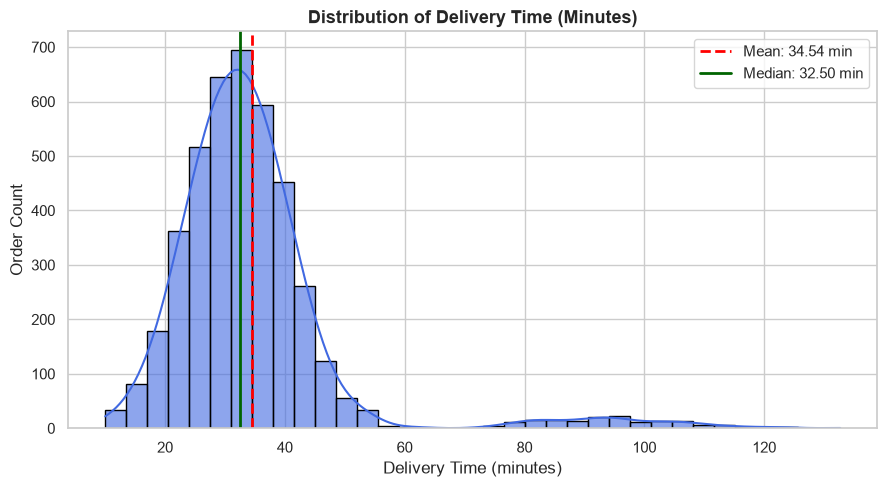

Skewness: 2.877
Mean Delivery Time: 34.54 minutes
Median Delivery Time: 32.50 minutes


In [2]:
# Plot histogram with KDE overlay for delivery time
plt.figure(figsize=(9, 5))
sns.histplot(df['delivery_time_min'], kde=True, color='royalblue', bins=35, edgecolor='black', alpha=0.6)

# Calculate summary statistics
mean_delivery = df['delivery_time_min'].mean()
median_delivery = df['delivery_time_min'].median()
skewness_delivery = df['delivery_time_min'].skew()

# Add vertical reference lines for mean and median
plt.axvline(mean_delivery, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_delivery:.2f} min')
plt.axvline(median_delivery, color='darkgreen', linestyle='-', linewidth=2, label=f'Median: {median_delivery:.2f} min')

plt.title('Distribution of Delivery Time (Minutes)', fontsize=13, weight='bold')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Order Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Skewness: {skewness_delivery:.3f}")
print(f"Mean Delivery Time: {mean_delivery:.2f} minutes")
print(f"Median Delivery Time: {median_delivery:.2f} minutes")

**Recommendation & Analysis:**  
We should advertise the **median (32.50 minutes)** rather than the mean (34.54 minutes) because the distribution is heavily right-skewed (skewness of +2.88) with a long tail of delayed orders reaching up to 114+ minutes. The median represents what a typical customer actually experiences on a normal day, whereas the mean gets unfairly dragged upwards by extreme operational bottlenecks.

---
## Task 2: Categorical × Numerical Relationships (Beyond the Average)
**Goal:** Examine customer rating by city using a violin plot and a strip plot (jittered). Identify which city shows the most inconsistent customer experience (wide spread or bimodal pattern) rather than just a low average rating.

/var/folders/_2/0xvt817s4ssbj4j5vbjc_05r0000gn/T/ipykernel_22936/2896231148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='city', y='rating', ax=axes[0], palette='Blues', inner='quartile')
/var/folders/_2/0xvt817s4ssbj4j5vbjc_05r0000gn/T/ipykernel_22936/2896231148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='city', y='rating', ax=axes[1], jitter=0.25, size=4, alpha=0.35, palette='Dark2')


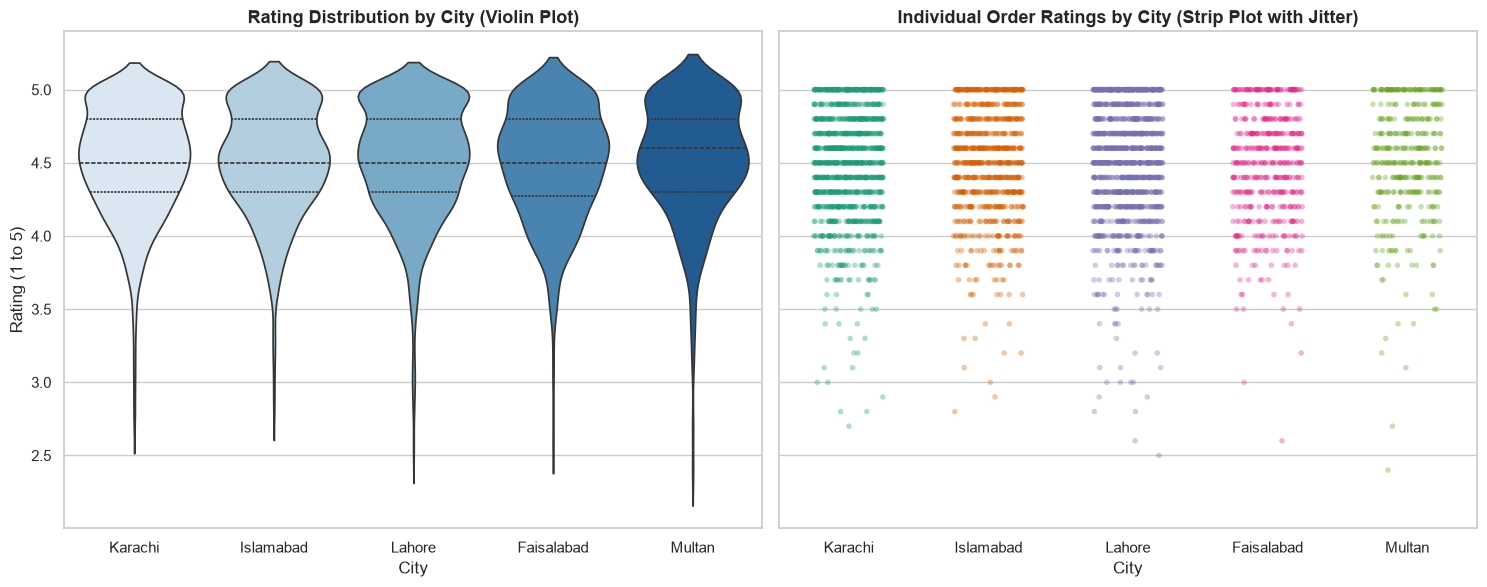

,count,mean,median,std,min,max
city,,,,,,
Faisalabad,492,4.490,4.5,0.384,2.6,5.0
Islamabad,835,4.512,4.5,0.374,2.8,5.0
Karachi,1163,4.508,4.5,0.380,2.7,5.0
Lahore,1324,4.511,4.5,0.397,2.5,5.0
Multan,386,4.521,4.6,0.401,2.4,5.0


In [3]:
# Build side-by-side violin plot and strip plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Violin plot to show density distribution per city
sns.violinplot(data=df, x='city', y='rating', ax=axes[0], palette='Blues', inner='quartile')
axes[0].set_title('Rating Distribution by City (Violin Plot)', fontsize=13, weight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Rating (1 to 5)')

# Strip plot with jitter to show individual order points and sample density
sns.stripplot(data=df, x='city', y='rating', ax=axes[1], jitter=0.25, size=4, alpha=0.35, palette='Dark2')
axes[1].set_title('Individual Order Ratings by City (Strip Plot with Jitter)', fontsize=13, weight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Rating (1 to 5)')

plt.tight_layout()
plt.show()

# Print detailed summary statistics per city
city_stats = df.groupby('city')['rating'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(3)
city_stats

**Explanation:**  
**Multan** (followed closely by Lahore) exhibits the most inconsistent customer experience because it has the widest spread of ratings (spanning from 2.4 to 5.0, with the highest standard deviation of 0.401). While Multan's average rating looks fine on paper (4.52), the violin and strip plots reveal a long, scattered tail of very dissatisfied customers that would be completely hidden by a simple bar chart of averages.

---
## Task 3: Multivariate Encoding
**Goal:** Build a single scatter plot of `delivery_time_min` vs. `rating`, encoding `city` with hue and `order_value` with bubble size. State whether high-value orders get faster or better-rated delivery.

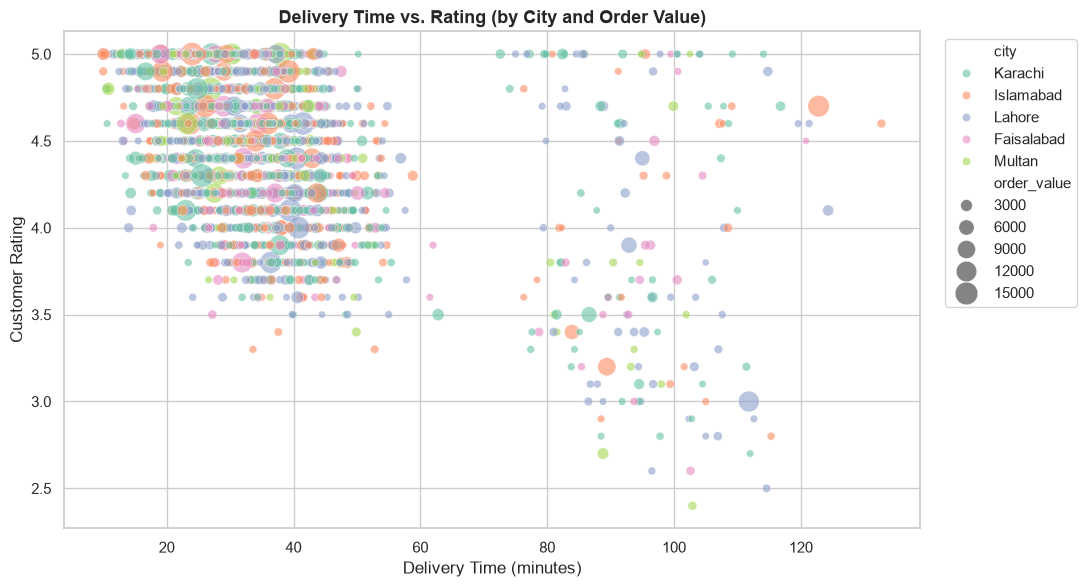

In [4]:
# Multivariate scatter plot with 4 variables:
# X: delivery_time_min, Y: rating, Hue: city, Size: order_value
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x='delivery_time_min',
    y='rating',
    hue='city',
    size='order_value',
    sizes=(25, 280),
    alpha=0.6,
    palette='Set2'
)

plt.title('Delivery Time vs. Rating (by City and Order Value)', fontsize=13, weight='bold')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Customer Rating')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Pattern Observed:**  
The 4-variable encoding reveals that high-value orders (the larger bubbles) do **not** receive faster delivery or systematically better ratings. In fact, high-value orders are scattered evenly across the delivery time range (averaging ~38.4 minutes vs 34.5 minutes overall), and when they suffer delivery delays beyond 80 minutes, their ratings drop just as low (to 3.0–3.5) as smaller orders across all cities.

---
## Task 4: Correlation (Pearson vs. Spearman)
**Goal:** Compute Pearson and Spearman correlation matrices for numeric columns, identify the pair where they disagree most, determine whether extreme outliers or non-linear trends drive the difference, justify whether outliers should be dropped, and include the correlation-is-not-causation caveat.

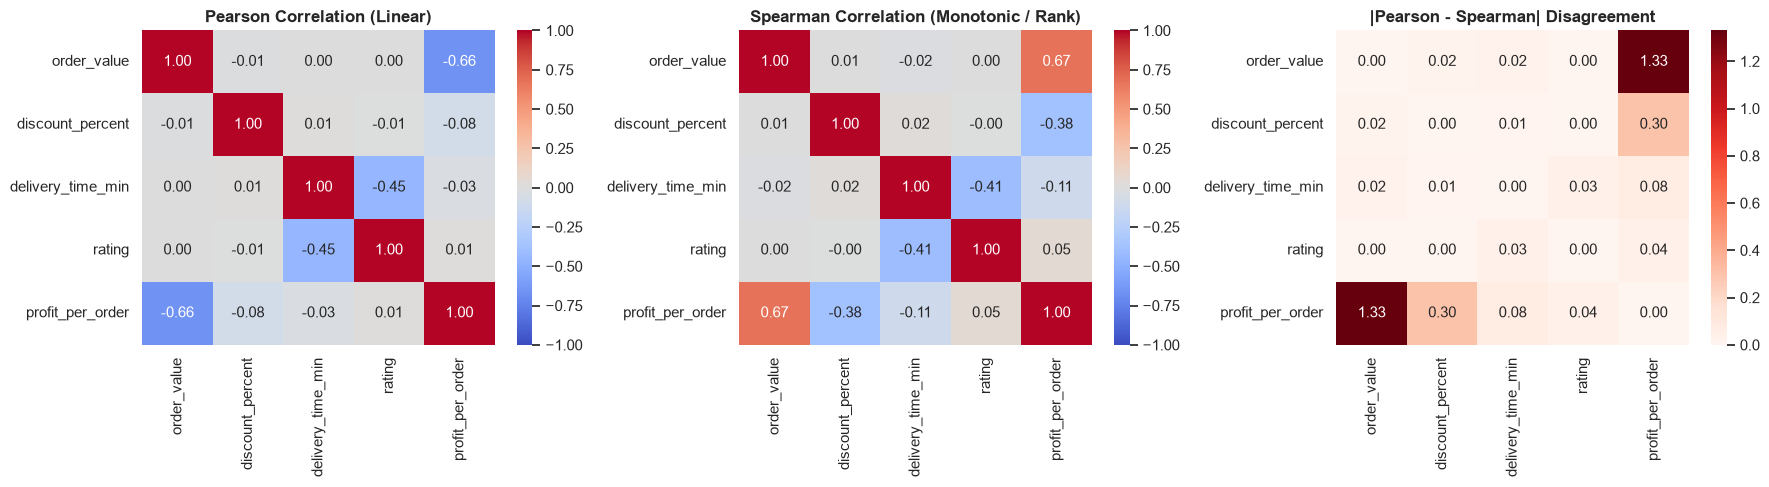

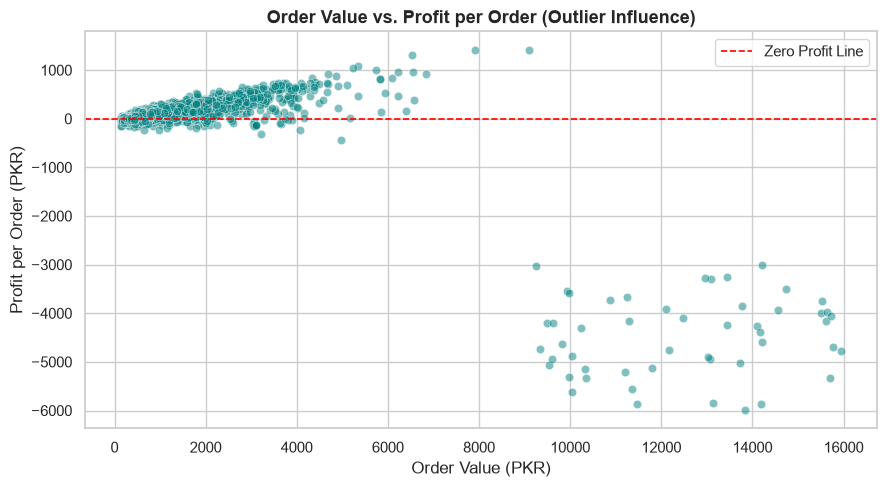

Pearson (order_value vs profit): -0.657
Spearman (order_value vs profit): 0.673
Number of orders with profit < -1000: 50


In [5]:
# Select numeric columns
num_cols = ['order_value', 'discount_percent', 'delivery_time_min', 'rating', 'profit_per_order']

# Compute Pearson and Spearman correlation matrices
pearson_corr = df[num_cols].corr(method='pearson')
spearman_corr = df[num_cols].corr(method='spearman')
diff_corr = (pearson_corr - spearman_corr).abs()

# Plot heatmaps side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Correlation (Linear)', fontsize=12, weight='bold')

sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Correlation (Monotonic / Rank)', fontsize=12, weight='bold')

sns.heatmap(diff_corr, annot=True, fmt='.2f', cmap='Reds', ax=axes[2])
axes[2].set_title('|Pearson - Spearman| Disagreement', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

# Scatter plot of the highest disagreement pair: order_value vs profit_per_order
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='order_value', y='profit_per_order', alpha=0.5, color='teal')
plt.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Zero Profit Line')
plt.title('Order Value vs. Profit per Order (Outlier Influence)', fontsize=13, weight='bold')
plt.xlabel('Order Value (PKR)')
plt.ylabel('Profit per Order (PKR)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Pearson (order_value vs profit): {pearson_corr.loc['order_value', 'profit_per_order']:.3f}")
print(f"Spearman (order_value vs profit): {spearman_corr.loc['order_value', 'profit_per_order']:.3f}")
print(f"Number of orders with profit < -1000: {(df['profit_per_order'] < -1000).sum()}")

**Analytical Findings:**  
1. **Disagreement Pair:** The two methods disagree the most on **`order_value` and `profit_per_order`**, where Pearson indicates a strong negative relationship (**-0.66**) while Spearman indicates a strong positive relationship (**+0.67**), resulting in a massive difference of **1.33**.
2. **Underlying Driver:** This disagreement is caused by a small group of extreme orders (specifically 50 high-value orders that suffered severe negative profits between -3,000 and -6,000 PKR). Because Pearson squares deviations from the mean, these 50 extreme losses completely drag the linear correlation negative. Spearman uses ranks, so those 50 orders only occupy the 50 lowest ranks, keeping the true general pattern visible: higher order values typically mean higher profits.
3. **Outlier Decision for Management:** We should **not** simply delete these extreme orders before reporting, because these negative profits are genuine financial losses (likely from refunds, vendor penalties, or promo exploitation) that management must address. Instead, we should report the Spearman correlation (or Pearson on typical orders, which is **+0.84**) to represent normal operations, while providing a dedicated outlier analysis on those 50 loss-making orders to plug profit leaks.
4. **Mandatory Caveat:** **Correlation is not causation.** Two variables moving together does not imply that one directly causes the other; they may be influenced by external factors such as discount rates, food costs, or unexpected order cancellations.

---
## Task 5: Layered Aggregation (pivot_table and Diverging Heatmap)
**Goal:** Using `pivot_table`, build a `city` × `restaurant_category` table of average `profit_per_order` with `margins=True`. Render it as a heatmap with a diverging palette centered at 0. Identify the most profitable combination per order, and check whether it is also the top revenue generator.

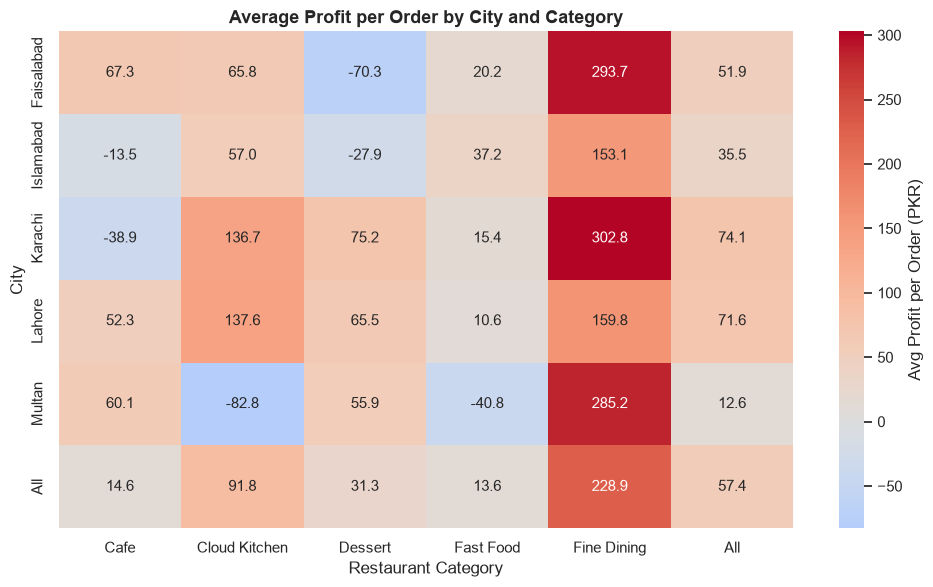

--- Total Revenue (Sum of Order Value in PKR) ---


restaurant_category,Cafe,Cloud Kitchen,Dessert,Fast Food,Fine Dining,All
city,,,,,,
Faisalabad,56093.00,205515.67,58415.97,145852.94,123173.00,589050.59
Islamabad,116804.47,342842.35,105370.12,203444.04,270610.22,1039071.19
Karachi,205017.31,371410.10,79235.00,288490.38,371893.00,1316045.79
Lahore,171131.14,449766.65,101385.00,379476.87,336923.84,1438683.50
Multan,51438.00,181931.62,25374.00,100182.58,81485.00,440411.19
All,600483.92,1551466.38,369780.09,1117446.81,1184085.06,4823262.26


In [6]:
# Build pivot table of average profit per order
profit_pivot = pd.pivot_table(
    df,
    index='city',
    columns='restaurant_category',
    values='profit_per_order',
    aggfunc='mean',
    margins=True
)

# Build pivot table of total revenue (sum of order_value)
revenue_pivot = pd.pivot_table(
    df,
    index='city',
    columns='restaurant_category',
    values='order_value',
    aggfunc='sum',
    margins=True
)

# Plot heatmap with diverging palette centered at 0
plt.figure(figsize=(10, 6))
sns.heatmap(
    profit_pivot,
    annot=True,
    fmt='.1f',
    cmap='coolwarm',
    center=0,
    cbar_kws={'label': 'Avg Profit per Order (PKR)'}
)
plt.title('Average Profit per Order by City and Category', fontsize=13, weight='bold')
plt.xlabel('Restaurant Category')
plt.ylabel('City')
plt.tight_layout()
plt.show()

print("--- Total Revenue (Sum of Order Value in PKR) ---")
display(revenue_pivot.round(2))

**Analytical Findings:**  
- **Most Profitable Combination per Order:** **Karachi × Fine Dining** is the most profitable combination, earning an average profit of **302.8 PKR per order** (with Faisalabad Fine Dining second at 293.7 PKR).
- **Revenue Comparison:** That combination is **not** the top revenue generator; high revenue and high profitability point to different combinations because **Lahore × Cloud Kitchen** produces the highest total revenue (449,766.65 PKR) due to massive order volume, whereas Karachi Fine Dining yields the highest margin per individual order on fewer transactions.

---
## Task 6: Time-Series Analysis (Trend vs. Noise)
**Goal:** Resample the data to get average monthly rating (not sales) and overlay a 3-month rolling average. State whether customer satisfaction is trending up, down, or flat once noise is smoothed out, and whether the raw line would lead to a different conclusion.

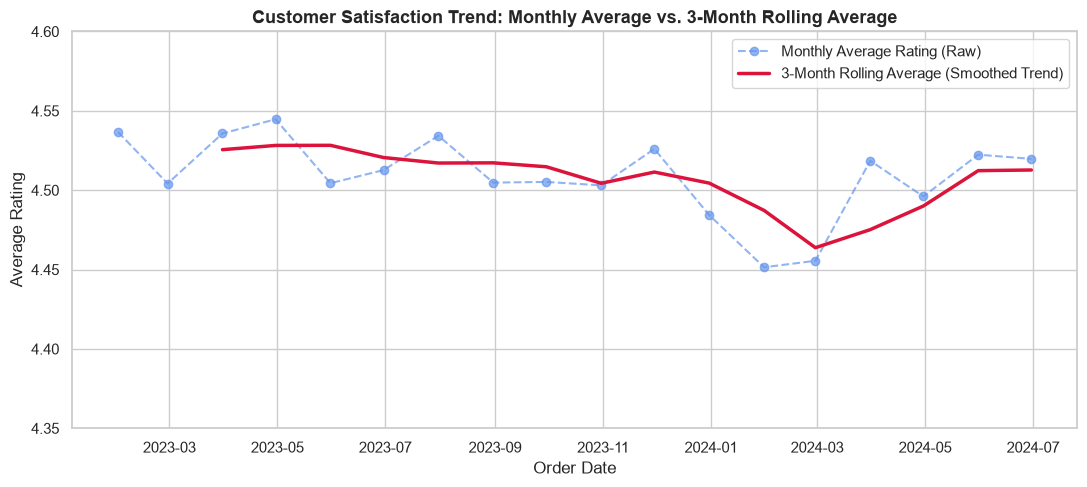

Monthly Rating Summary:
order_date
2024-01-31    4.451
2024-02-29    4.456
2024-03-31    4.519
2024-04-30    4.496
2024-05-31    4.522
2024-06-30    4.520
Freq: ME, Name: rating, dtype: float64


In [7]:
# Set date as index and sort chronologically
df_time = df.set_index('order_date').sort_index()

# Resample to monthly average rating and calculate 3-month rolling average
monthly_rating = df_time['rating'].resample('ME').mean()
rolling_3m = monthly_rating.rolling(window=3).mean()

# Plot raw monthly vs rolling average
plt.figure(figsize=(11, 5))
plt.plot(monthly_rating.index, monthly_rating.values, marker='o', linestyle='--', color='cornflowerblue', alpha=0.7, label='Monthly Average Rating (Raw)')
plt.plot(rolling_3m.index, rolling_3m.values, color='crimson', linewidth=2.5, label='3-Month Rolling Average (Smoothed Trend)')

plt.title('Customer Satisfaction Trend: Monthly Average vs. 3-Month Rolling Average', fontsize=13, weight='bold')
plt.xlabel('Order Date')
plt.ylabel('Average Rating')
plt.ylim(4.35, 4.60)
plt.legend()
plt.tight_layout()
plt.show()

print("Monthly Rating Summary:")
print(monthly_rating.tail(6).round(3))

**Explanation:**  
Once month-to-month noise is smoothed out with the 3-month rolling average, customer satisfaction is essentially **flat** over the entire 18 months, consistently hovering between 4.49 and 4.53 aside from a short dip in winter (Jan–Feb 2024). Looking at the raw monthly line alone would easily lead to the wrong conclusion, because its sharp zig-zags make normal monthly noise look like alarming crashes or sudden improvements.

---
## Task 7: Faceting (Small Multiples for Multivariate Comparison)
**Goal:** Using `FacetGrid`, facet `delivery_time_min` vs. `rating` scatter plots by `restaurant_category` (columns) and by whether the order was heavily discounted (`discount_percent > 20`, as hue). Identify a category where discounting visibly changes customer forgiveness for slow deliveries.

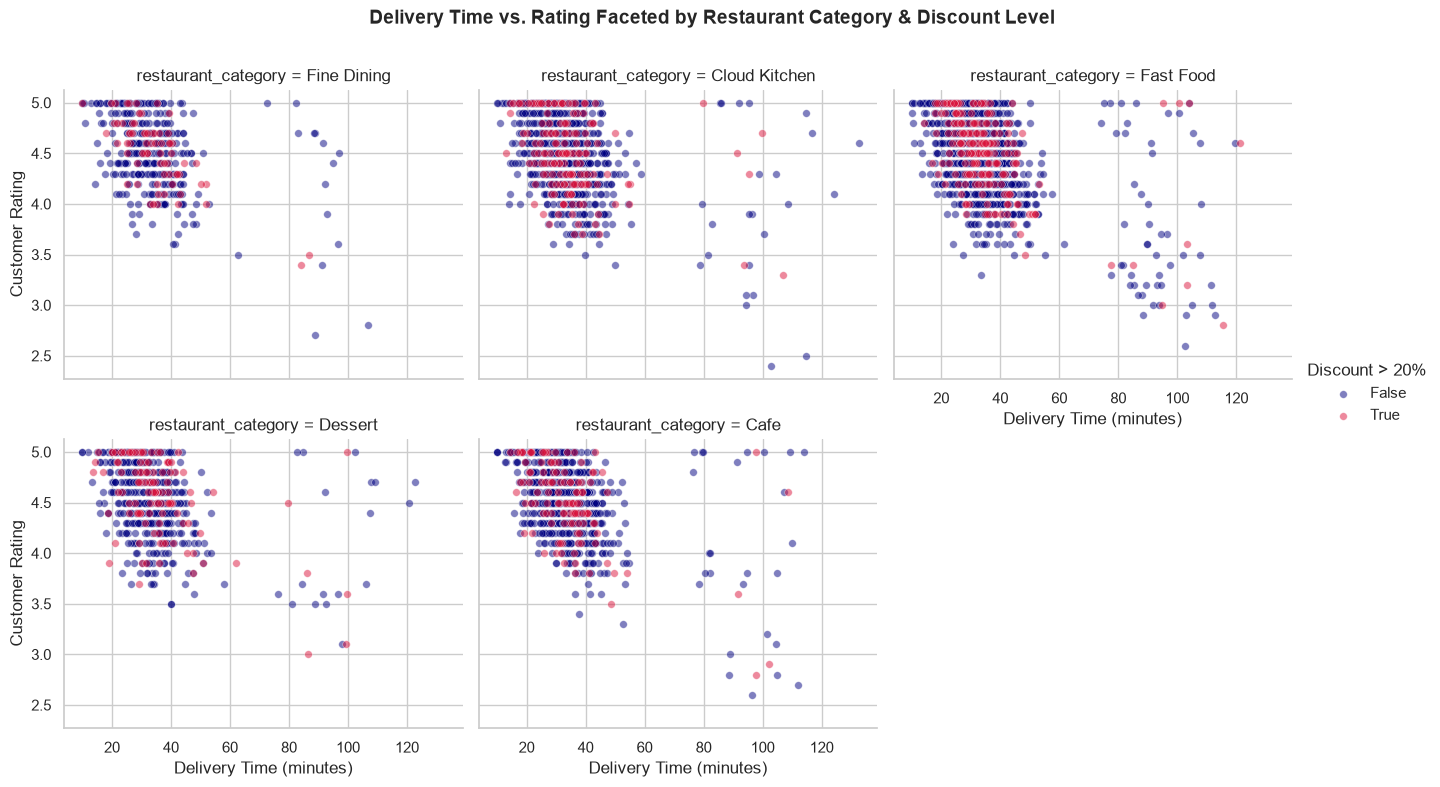

Delivery Time vs Rating Correlation by Category:
 - Cafe            | Heavy Discount (>20%): -0.519 | Regular: -0.460
 - Cloud Kitchen   | Heavy Discount (>20%): -0.329 | Regular: -0.400
 - Dessert         | Heavy Discount (>20%): -0.516 | Regular: -0.340
 - Fast Food       | Heavy Discount (>20%): -0.469 | Regular: -0.503
 - Fine Dining     | Heavy Discount (>20%): -0.737 | Regular: -0.402


In [8]:
# Create heavy discount indicator
df['heavily_discounted'] = df['discount_percent'] > 20

# Create FacetGrid across restaurant categories
g = sns.FacetGrid(
    df,
    col='restaurant_category',
    hue='heavily_discounted',
    col_wrap=3,
    height=4,
    aspect=1.1,
    palette={True: 'crimson', False: 'navy'}
)

g.map(sns.scatterplot, 'delivery_time_min', 'rating', alpha=0.5, s=30)
g.add_legend(title='Discount > 20%')
g.set_axis_labels('Delivery Time (minutes)', 'Customer Rating')
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('Delivery Time vs. Rating Faceted by Restaurant Category & Discount Level', fontsize=14, weight='bold')
plt.show()

# Correlation between delivery time and rating for heavily discounted vs regular orders per category
print("Delivery Time vs Rating Correlation by Category:")
for cat, grp in df.groupby('restaurant_category'):
    c_disc = grp[grp['heavily_discounted']][['delivery_time_min', 'rating']].corr().iloc[0,1]
    c_reg = grp[~grp['heavily_discounted']][['delivery_time_min', 'rating']].corr().iloc[0,1]
    print(f" - {cat:15s} | Heavy Discount (>20%): {c_disc:.3f} | Regular: {c_reg:.3f}")

**Analytical Finding:**  
In **Fine Dining**, heavy discounting visibly changes customer expectations: when fine dining deliveries are delayed, heavily discounted orders suffer a much sharper drop in ratings (correlation worsens to **-0.737** vs **-0.402** for regular orders). This indicates that fine dining customers expecting high-end food do not become more lenient just because they received a discount; if it arrives cold or late, their disappointment is even stronger.

---
## Task 8: Overplotting and Targeted Annotations
**Goal:** Plot the raw order-level `delivery_time_min` vs. `rating` scatter plot. Fix overplotting using alpha or hexbin (justifying the choice), and annotate:
1. The order with the best rating despite an unusually long delivery time.
2. The order with the worst rating despite an unusually fast delivery.

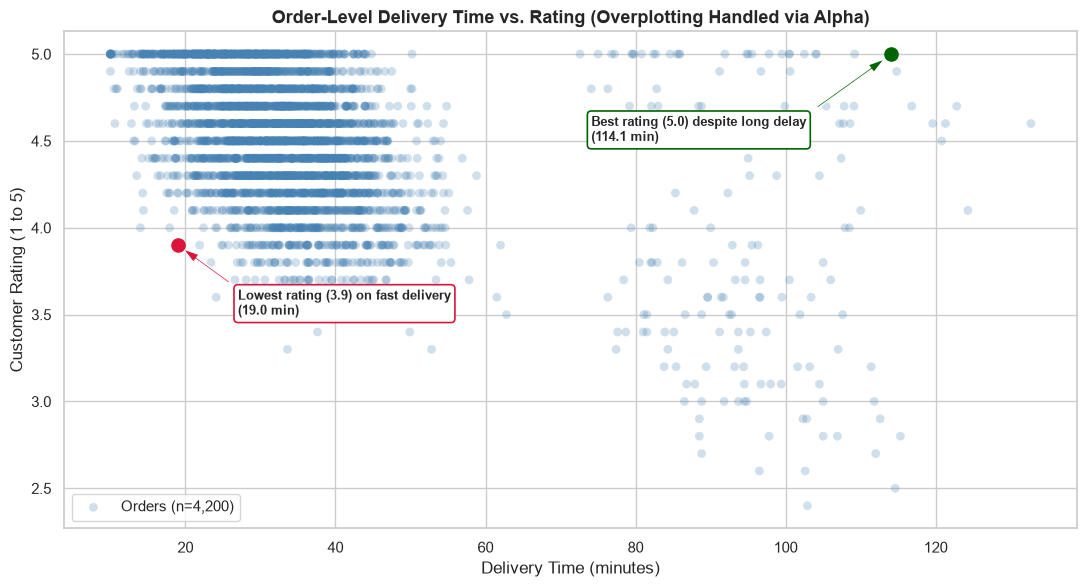

Annotated Order 1 (High Rating Despite Long Delivery):
order_date             2024-04-30 00:00:00
city                               Karachi
restaurant_category                   Cafe
delivery_time_min                    114.1
rating                                 5.0
order_value                          507.0
Name: 3723, dtype: object

Annotated Order 2 (Low Rating Despite Fast Delivery):
order_date             2024-02-11 00:00:00
city                             Islamabad
restaurant_category                Dessert
delivery_time_min                     19.0
rating                                 3.9
order_value                          339.0
Name: 3114, dtype: object


In [9]:
# Identify the two specific outlier orders to annotate:
# 1. Best rating (5.0) with the longest delivery time
best_slow = df[df['rating'] == 5.0].sort_values('delivery_time_min', ascending=False).iloc[0]

# 2. Worst rating despite unusually fast delivery (delivery time <= 20 min)
worst_fast = df[df['delivery_time_min'] <= 20.0].sort_values('rating', ascending=True).iloc[0]

plt.figure(figsize=(11, 6))

# Apply alpha transparency to resolve overplotting across 4,200 points
plt.scatter(
    df['delivery_time_min'],
    df['rating'],
    alpha=0.25,
    color='steelblue',
    edgecolors='none',
    s=40,
    label='Orders (n=4,200)'
)

# Highlight and annotate Outlier 1: Best rating with long delay
plt.scatter(best_slow['delivery_time_min'], best_slow['rating'], color='darkgreen', s=90, zorder=5)
plt.annotate(
    f"Best rating (5.0) despite long delay\n({best_slow['delivery_time_min']:.1f} min)",
    xy=(best_slow['delivery_time_min'], best_slow['rating']),
    xytext=(best_slow['delivery_time_min'] - 40, best_slow['rating'] - 0.5),
    arrowprops=dict(facecolor='darkgreen', shrink=0.08, width=1.5, headwidth=7),
    fontsize=9.5,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkgreen", lw=1.2)
)

# Highlight and annotate Outlier 2: Lowest rating on fast delivery
plt.scatter(worst_fast['delivery_time_min'], worst_fast['rating'], color='crimson', s=90, zorder=5)
plt.annotate(
    f"Lowest rating ({worst_fast['rating']:.1f}) on fast delivery\n({worst_fast['delivery_time_min']:.1f} min)",
    xy=(worst_fast['delivery_time_min'], worst_fast['rating']),
    xytext=(worst_fast['delivery_time_min'] + 8, worst_fast['rating'] - 0.4),
    arrowprops=dict(facecolor='crimson', shrink=0.08, width=1.5, headwidth=7),
    fontsize=9.5,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", lw=1.2)
)

plt.title('Order-Level Delivery Time vs. Rating (Overplotting Handled via Alpha)', fontsize=13, weight='bold')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Customer Rating (1 to 5)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

print("Annotated Order 1 (High Rating Despite Long Delivery):")
print(best_slow[['order_date', 'city', 'restaurant_category', 'delivery_time_min', 'rating', 'order_value']])

print("\nAnnotated Order 2 (Low Rating Despite Fast Delivery):")
print(worst_fast[['order_date', 'city', 'restaurant_category', 'delivery_time_min', 'rating', 'order_value']])

**Technique Choice & Justification:**  
We chose **transparency (`alpha=0.25`)** over hexbinning because with 4,200 data points (a few thousand points), transparency clearly shows where the bulk of points cluster along the discrete rating lines while still keeping individual transaction points visible for targeted outlier annotation. Hexbinning is suited for massive datasets (50,000+ points) and would convert the data into hexagonal blocks, hiding the specific outlier points we need to annotate.